In [1]:
# Top 10 Medicaid Drugs — Interactive Plot



# !pip install plotly

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. LOAD & CLEAN DATA


df = pd.read_csv("https://download.medicaid.gov/data/sdud-2025-updated-dec2025.csv")

# Remove suppressed rows
df = df[df["Suppression Used"] == False].copy()

# Normalize drug names
df["Drug"] = df["Product Name"].str.upper().str.strip()
df["State"] = df["State"].str.strip()

# ── 2. AGGREGATE — TOP 10 DRUGS
top10 = (
    df.groupby("Drug")
    .agg(
        Total_Reimbursed=("Total Amount Reimbursed", "sum"),
        Total_Rx=("Number of Prescriptions", "sum"),
        Total_Units=("Units Reimbursed", "sum"),
    )
    .nlargest(10, "Total_Reimbursed")
    .reset_index()
)

top10_drug_list = top10["Drug"].tolist()

# ── 3. AGGREGATE — STATE BREAKDOWN FOR TOP 10
state_df = (
    df[df["Drug"].isin(top10_drug_list) & (df["State"] != "XX")]
    .groupby(["Drug", "State"])
    .agg(
        Total_Reimbursed=("Total Amount Reimbursed", "sum"),
        Total_Rx=("Number of Prescriptions", "sum"),
    )
    .reset_index()
)

# ── 4. OVERVIEW CHART — Top 10 by Total Reimbursement
COLORS = px.colors.qualitative.Bold

fig_overview = px.bar(
    top10.sort_values("Total_Reimbursed"),
    x="Total_Reimbursed",
    y="Drug",
    orientation="h",
    color="Drug",
    color_discrete_sequence=COLORS,
    text=top10.sort_values("Total_Reimbursed")["Total_Reimbursed"].apply(
        lambda v: f"${v/1e9:.2f}B" if v >= 1e9 else f"${v/1e6:.1f}M"
    ),
    custom_data=["Total_Rx", "Total_Units"],
    title="<b>Top 10 Drugs by Total Medicaid Reimbursement (2025)</b><br>"
          "<sup>Source: CMS State Drug Utilization Data — Q1 & Q2, suppressed records excluded</sup>",
)

fig_overview.update_traces(
    textposition="outside",
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Total Reimbursed: $%{x:,.0f}<br>"
        "Prescriptions: %{customdata[0]:,.0f}<br>"
        "Units Reimbursed: %{customdata[1]:,.0f}<extra></extra>"
    ),
)

fig_overview.update_layout(
    height=520,
    showlegend=False,
    xaxis=dict(
        title="Total Amount Reimbursed ($)",
        tickformat="$,.0f",
        gridcolor="rgba(0,0,0,0.07)",
    ),
    yaxis=dict(title=""),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=13),
    margin=dict(l=20, r=120, t=80, b=40),
)

fig_overview.show()
print("✅ Overview chart rendered.\n")

# ── 5. STATE BREAKDOWN — Dropdown to pick drug
fig_state = go.Figure()

for i, drug in enumerate(top10_drug_list):
    subset = state_df[state_df["Drug"] == drug].sort_values("Total_Reimbursed")
    fig_state.add_trace(
        go.Bar(
            x=subset["Total_Reimbursed"],
            y=subset["State"],
            orientation="h",
            name=drug,
            visible=(i == 0),
            marker_color=COLORS[i % len(COLORS)],
            customdata=subset[["Total_Rx"]].values,
            hovertemplate=(
                f"<b>{drug}</b> — <b>%{{y}}</b><br>"
                "Total Reimbursed: $%{x:,.0f}<br>"
                "Prescriptions: %{customdata[0]:,.0f}<extra></extra>"
            ),
        )
    )

# Build dropdown buttons — one per drug
buttons = []
for i, drug in enumerate(top10_drug_list):
    visibility = [j == i for j in range(len(top10_drug_list))]
    buttons.append(
        dict(
            label=drug,
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"<b>{drug}</b> — Reimbursement by State (2025)"},
            ],
        )
    )

fig_state.update_layout(
    title=f"<b>{top10_drug_list[0]}</b> — Reimbursement by State (2025)",
    height=650,
    showlegend=False,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.01,
            xanchor="left",
            y=1.12,
            yanchor="top",
            bgcolor="white",
            bordercolor="#ccc",
            font=dict(size=12),
        )
    ],
    xaxis=dict(
        title="Total Amount Reimbursed ($)",
        tickformat="$,.0f",
        gridcolor="rgba(0,0,0,0.07)",
    ),
    yaxis=dict(title="State", autorange=True),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=12),
    margin=dict(l=20, r=40, t=100, b=40),
    annotations=[
        dict(
            text="Select drug:",
            x=0.01, y=1.085,
            xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=12, color="#555"),
        )
    ],
)

fig_state.show()
print("✅ State breakdown chart rendered.")
print("   Use the dropdown at the top-left to switch between drugs.")

# ── 6. BONUS — Side-by-side: Reimbursement vs Rx count ──────
fig_compare = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Total Amount Reimbursed ($)", "Number of Prescriptions"),
    horizontal_spacing=0.12,
)

top10_sorted = top10.sort_values("Total_Reimbursed")

fig_compare.add_trace(
    go.Bar(
        x=top10_sorted["Total_Reimbursed"],
        y=top10_sorted["Drug"],
        orientation="h",
        marker_color=COLORS[:10],
        hovertemplate="<b>%{y}</b><br>$%{x:,.0f}<extra></extra>",
        showlegend=False,
    ),
    row=1, col=1,
)

top10_rx_sorted = top10.sort_values("Total_Rx")
fig_compare.add_trace(
    go.Bar(
        x=top10_rx_sorted["Total_Rx"],
        y=top10_rx_sorted["Drug"],
        orientation="h",
        marker_color=COLORS[:10],
        hovertemplate="<b>%{y}</b><br>%{x:,.0f} Rx<extra></extra>",
        showlegend=False,
    ),
    row=1, col=2,
)

fig_compare.update_layout(
    title="<b>Top 10 Drugs — Reimbursement vs Prescription Volume (2025)</b>",
    height=480,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=12),
    margin=dict(l=20, r=20, t=80, b=40),
)
fig_compare.update_xaxes(tickformat="$,.0f", row=1, col=1, gridcolor="rgba(0,0,0,0.07)")
fig_compare.update_xaxes(tickformat=",", row=1, col=2, gridcolor="rgba(0,0,0,0.07)")

fig_compare.show()
print("✅ Comparison chart rendered.")


✅ Overview chart rendered.



✅ State breakdown chart rendered.
   Use the dropdown at the top-left to switch between drugs.


✅ Comparison chart rendered.


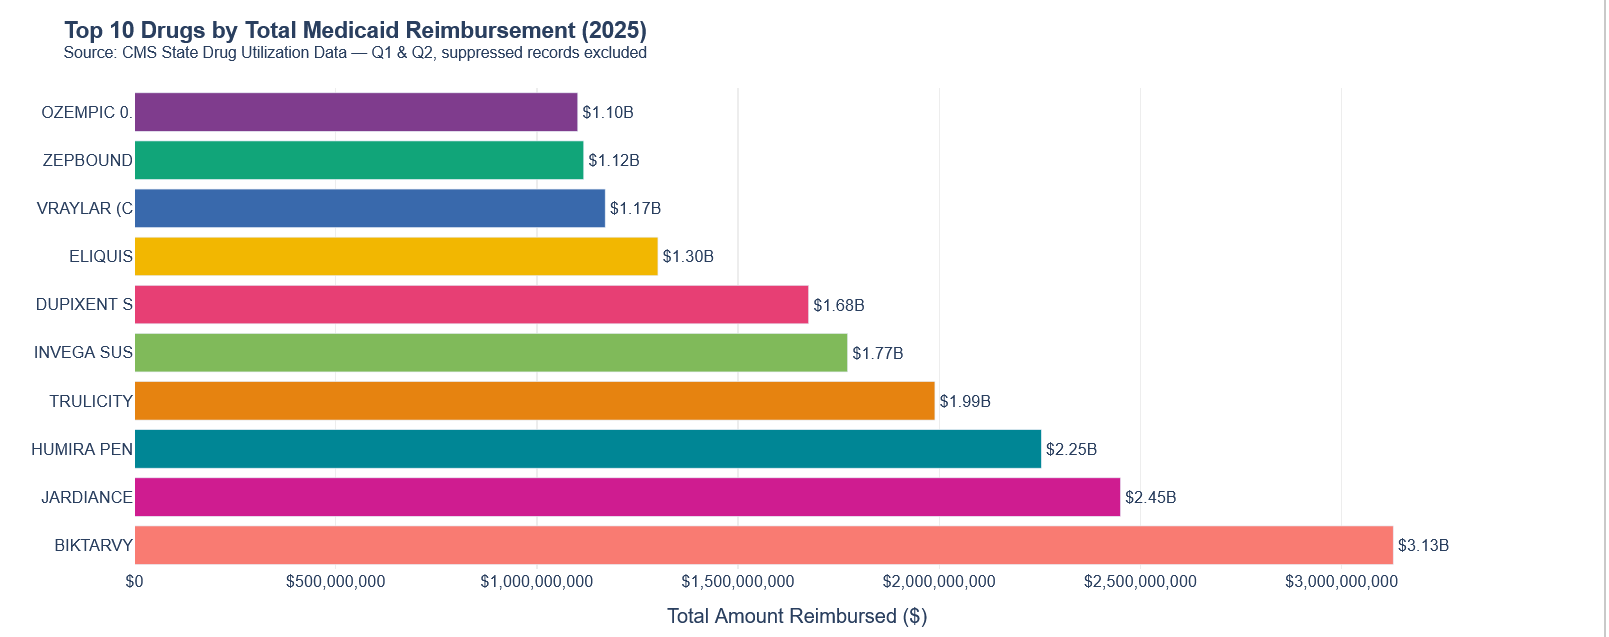

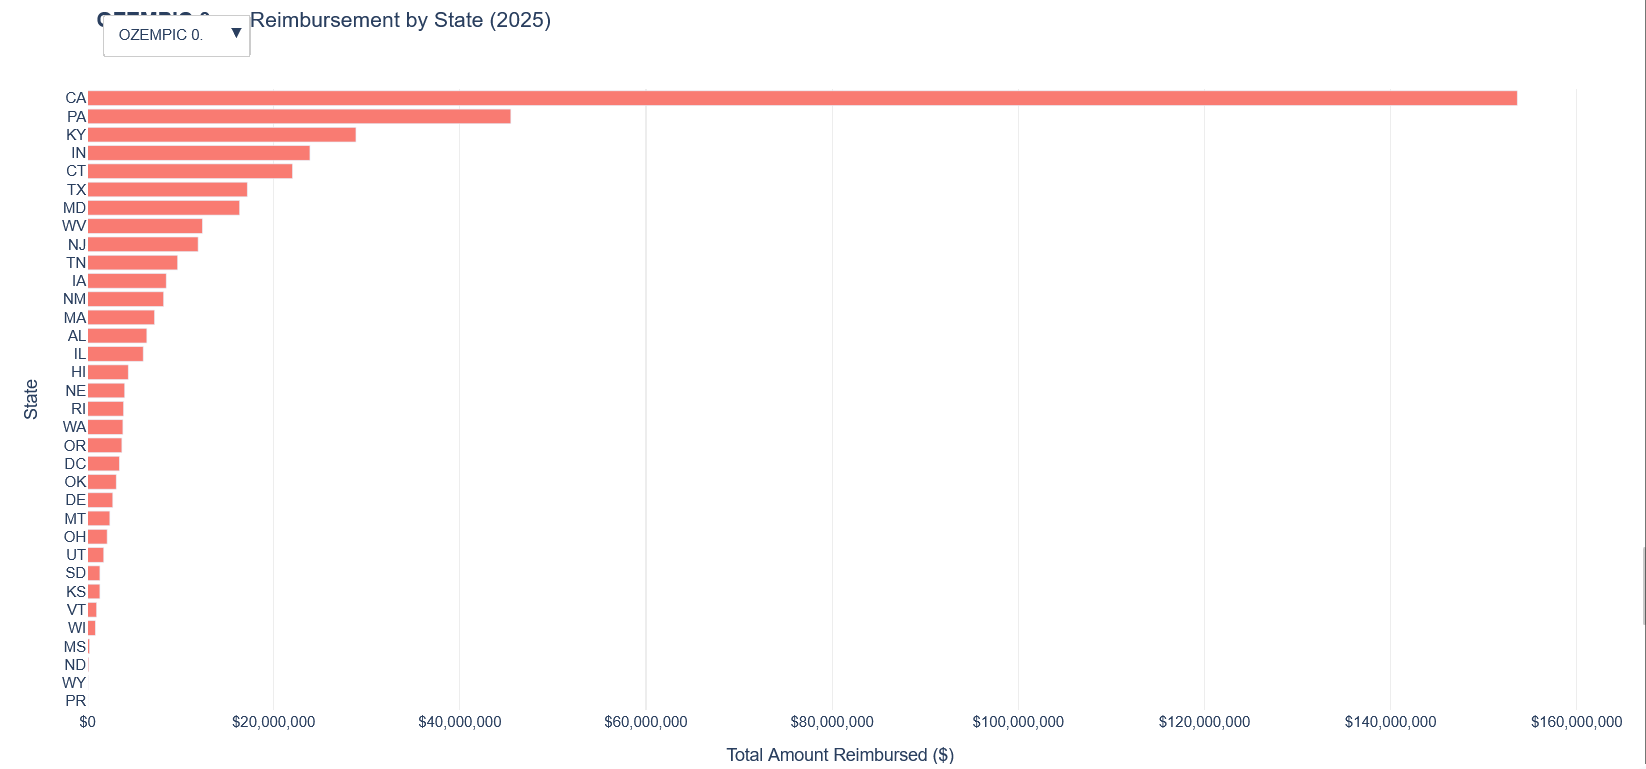

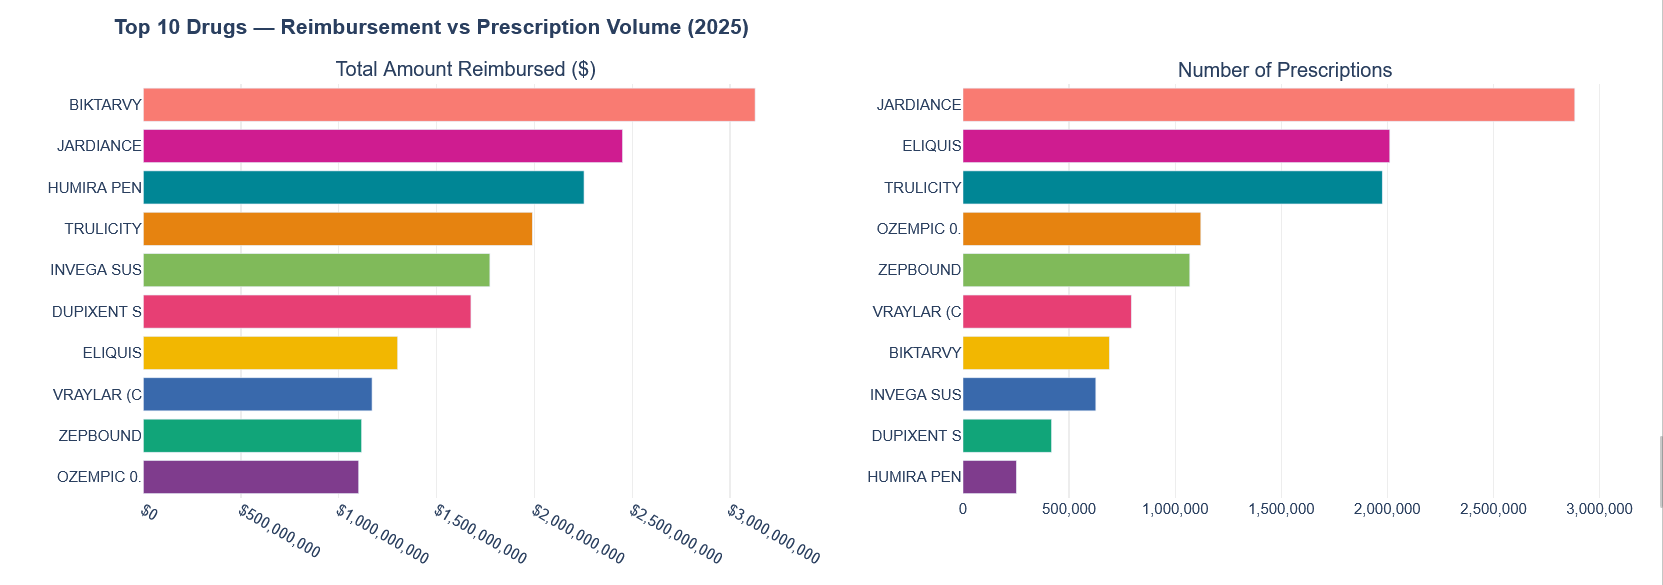

*Note: The above charts are screenshots for GitHub upload purposes only. Plotly does not render interactive charts in GitHub. To view the full charts please run the files for the interactivity.